<a href="https://colab.research.google.com/github/padhikari26/Covid-19_ResearchProject/blob/main/Spotify_Top_Songs_2023_Extensive_Data_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1. Importing Required Dependencies for the Project

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#!pip install pandas
import pandas as pd

#!pip install numpy
import numpy as np

#!pip install matplotlib
import matplotlib.pyplot as plt

#!pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

#!pip install scikit-learn
from sklearn import datasets, model_selection
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression

# Step 2. Imported the DataSet

In [ ]:
file_path = "spotify-2023.csv"
spotify_df = kagglehub.load_dataset(
KaggleDatasetAdapter.PANDAS,"nelgiriyewithana/top-spotify-songs-2023",file_path, pandas_kwargs={'encoding': 'latin-1'})

100%|██████████| 104k/104k [00:00<00:00, 1.41MB/s]


In [ ]:
spotify_df.head(18)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6
5,Sprinter,"Dave, Central Cee",2,2023,6,1,2186,91,183706234,67,...,141,C#,Major,92,66,58,19,0,8,24
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2,2023,3,16,3090,50,725980112,34,...,148,F,Minor,67,83,76,48,0,8,3
7,Columbia,Quevedo,1,2023,7,7,714,43,58149378,25,...,100,F,Major,67,26,71,37,0,11,4
8,fukumean,Gunna,1,2023,5,15,1096,83,95217315,60,...,130,C#,Minor,85,22,62,12,0,28,9
9,La Bebe - Remix,"Peso Pluma, Yng Lvcas",2,2023,3,17,2953,44,553634067,49,...,170,D,Minor,81,56,48,21,0,8,33


# Step 3. Doing Some Data Analysis and Figuring Out What to Clean and Filter

In [ ]:
spotify_df.rename(columns={'track_name': 'Tracks', 'artist(s)_name': 'Artists','artist_count': '# of Artists on Song','released_year': 'Year It Released','released_month': 'Month It Released','released_day': 'Day It Released','in_spotify_playlists': '# of Playlists The Song is in on Spotify','in_spotify_charts': 'Song Place in Spotify Charts','streams': '# of Streams the Song has','in_apple_playlists': '# of Playlists The Song is in on Apple Music','in_apple_charts': 'Song Place in Apple Music Charts','in_deezer_playlists': '# of Playlists the Song is in on Deezer','in_deezer_charts': 'Song Place in Deezer Charts','in_shazam_charts': 'Song Place in Shazam Charts','bpm': 'The BPM of the Song','key': 'The Key of the Song','mode': 'The Mode of the Song','danceability_%': 'How Danacable the song is by %','valence_%': 'How Positive the Song is in %','energy_%': 'Energy Level of the Song in %','acousticness_%': 'How Much Acoustic Sound is in the Song in %','instrumentalness_%': 'How Instrumental the Song is in %','liveness_%': 'The presence of special live performance effects in %','speechiness_%': '# of words sung in the song in %',}, inplace=True)

In [ ]:
spotify_df.columns

Index(['Tracks', 'Artists', '# of Artists on Song', 'Year It Released',
       'Month It Released', 'Day It Released',
       '# of Playlists The Song is in on Spotify',
       'Song Place in Spotify Charts', '# of Streams the Song has',
       '# of Playlists The Song is in on Apple Music',
       'Song Place in Apple Music Charts',
       '# of Playlists the Song is in on Deezer',
       'Song Place in Deezer Charts', 'Song Place in Shazam Charts',
       'The BPM of the Song', 'The Key of the Song', 'The Mode of the Song',
       'How Danacable the song is by %', 'How Positive the Song is in %',
       'Energy Level of the Song in %',
       'How Much Acoustic Sound is in the Song in %',
       'How Instrumental the Song is in %',
       'The presence of special live performance effects in %',
       '# of words sung in the song in %'],
      dtype='object')

In [ ]:
spotify_df.drop_duplicates(inplace=True)

In [ ]:
spotify_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   Tracks                                                 953 non-null    object
 1   Artists                                                953 non-null    object
 2   # of Artists on Song                                   953 non-null    int64 
 3   Year It Released                                       953 non-null    int64 
 4   Month It Released                                      953 non-null    int64 
 5   Day It Released                                        953 non-null    int64 
 6   # of Playlists The Song is in on Spotify               953 non-null    int64 
 7   Song Place in Spotify Charts                           953 non-null    int64 
 8   # of Streams the Song has                              953 n

In [ ]:
spotify_df.shape

(953, 24)

In [ ]:
spotify_df['The Key of the Song'].unique()

array(['B', 'C#', 'F', 'A', 'D', 'F#', nan, 'G#', 'G', 'E', 'A#', 'D#'],
      dtype=object)

# Step 4. Reasearch Questions To Think About!



Do these specific features of songs have the effect of the number of streams or charts?

Do these specific features of songs have the effect of the danceability and instrumental and acoustic?

Do these specific features of songs have the effect of the energy and # words sung and acoustic and artists?

# Step 5. Cleaning Up the Null Values In this DataSet

In [ ]:
spotify_df[spotify_df['The Key of the Song'].isnull()]

,Tracks,Artists,# of Artists on Song,Year It Released,Month It Released,Day It Released,# of Playlists The Song is in on Spotify,Song Place in Spotify Charts,# of Streams the Song has,# of Playlists The Song is in on Apple Music,...,The BPM of the Song,The Key of the Song,The Mode of the Song,How Danacable the song is by %,How Positive the Song is in %,Energy Level of the Song in %,How Much Acoustic Sound is in the Song in %,How Instrumental the Song is in %,The presence of special live performance effects in %,# of words sung in the song in %
12,Flowers,Miley Cyrus,1,2023,1,12,12211,115,1316855716,300,...,118,NaN,Major,71,65,68,6,0,3,7
17,What Was I Made For? [From The Motion Picture ...,Billie Eilish,1,2023,7,13,873,104,30546883,80,...,78,NaN,Major,44,14,9,96,0,10,3
22,I Wanna Be Yours,Arctic Monkeys,1,2013,1,1,12859,110,1297026226,24,...,135,NaN,Minor,48,44,42,12,2,11,3
35,Los del Espacio,"Big One, Duki, Lit Killah, Maria Becerra, FMK,...",8,2023,6,1,1150,31,123122413,22,...,120,NaN,Major,81,63,68,11,0,11,4
44,Barbie World (with Aqua) [From Barbie The Album],"Nicki Minaj, Aqua, Ice Spice",3,2023,6,23,1117,80,65156199,82,...,144,NaN,Major,77,75,58,52,0,23,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899,Hold Me Closer,"Elton John, Britney Spears",2,2017,11,10,4967,0,284216603,165,...,126,NaN,Major,67,49,77,11,0,19,11
901,After LIKE,IVE,1,2022,8,22,767,12,265548837,20,...,125,NaN,Major,68,80,92,10,0,9,12
903,B.O.T.A. (Baddest Of Them All) - Edit,"Interplanetary Criminal, Eliza Rose",2,2022,6,15,5153,6,244585109,102,...,137,NaN,Major,74,71,89,24,61,15,5
938,Labyrinth,Taylor Swift,1,2022,10,21,1597,0,187339835,6,...,110,NaN,Major,48,15,31,80,22,12,4


In [ ]:
null_shazam_values=spotify_df[spotify_df['Song Place in Shazam Charts'].isnull()]

print("Rows with null values in 'Song Place in Shazam Charts':")
null_shazam_values.head(50)

Rows with null values in 'Song Place in Shazam Charts':


,Tracks,Artists,# of Artists on Song,Year It Released,Month It Released,Day It Released,# of Playlists The Song is in on Spotify,Song Place in Spotify Charts,# of Streams the Song has,# of Playlists The Song is in on Apple Music,...,The BPM of the Song,The Key of the Song,The Mode of the Song,How Danacable the song is by %,How Positive the Song is in %,Energy Level of the Song in %,How Much Acoustic Sound is in the Song in %,How Instrumental the Song is in %,The presence of special live performance effects in %,# of words sung in the song in %
14,As It Was,Harry Styles,1,2022,3,31,23575,130,2513188493,403,...,174,F#,Minor,52,66,73,34,0,31,6
54,Another Love,Tom Odell,1,2012,10,15,18371,83,1813673666,250,...,123,E,Minor,45,13,54,70,0,9,4
55,Blinding Lights,The Weeknd,1,2019,11,29,43899,69,3703895074,672,...,171,C#,Major,50,38,80,0,0,9,7
71,Heat Waves,Glass Animals,1,2020,6,28,22543,63,2557975762,386,...,81,B,Major,76,53,53,44,0,9,9
73,Sweater Weather,The Neighbourhood,1,2012,5,14,16413,61,2282771485,166,...,124,A#,Major,61,41,81,5,2,10,3
86,Someone You Loved,Lewis Capaldi,1,2018,11,8,17836,53,2887241814,440,...,110,C#,Major,50,45,41,75,0,11,3
127,Watermelon Sugar,Harry Styles,1,2019,11,17,21915,34,2322580122,437,...,95,NaN,Major,55,56,82,12,0,34,5
158,Ghost,Justin Bieber,1,2021,3,19,5866,24,1167330737,107,...,154,D,Major,61,41,74,21,0,40,6
159,Under The Influence,Chris Brown,1,2019,10,4,3859,26,929964809,133,...,117,A,Minor,73,31,69,6,0,11,4
180,Night Changes,One Direction,1,2014,11,17,7124,18,1131090940,60,...,120,G#,Major,67,40,52,86,0,12,4


In [ ]:
import requests
import pandas as pd
import base64
import time

CLIENT_ID = 'c14c8649a3a347c18d92aa580551eb16'
CLIENT_SECRET = 'afd7cc8ec2314138ae5aae7c7cb54db9'

def get_token(client_id, client_secret):
    auth_str = f"{client_id}:{client_secret}"
    b64_auth_str = base64.b64encode(auth_str.encode()).decode()
    url = 'https://accounts.spotify.com/api/token'
    headers = {'Authorization': f'Basic {b64_auth_str}'}
    data = {'grant_type': 'client_credentials'}
    response = requests.post(url, headers=headers, data=data)
    return response.json()['access_token']

# 2. Spotify key map
key_map = {-1: 'Unknown',0: 'C',1: 'C♯/D♭',2: 'D',3: 'D♯/E♭',4: 'E',5: 'F',6: 'F♯/G♭',7: 'G',8: 'G♯/A♭',9: 'A',10: 'A♯/B♭',11: 'B'}

# 3. Search for track ID using name and artist
def search_track_id(track_name, artist_name, headers):
    query = f'track:{track_name} artist:{artist_name}'
    url = 'https://api.spotify.com/v1/search'
    params = {'q': query, 'type': 'track', 'limit': 1}
    response = requests.get(url, headers=headers, params=params)
    if response.status_code != 200:
        return None
    results = response.json()
    tracks = results.get('tracks', {}).get('items', [])
    return tracks[0]['id'] if tracks else None

# 4. Get the musical key using the track ID
def get_track_key(track_id, headers):
    if not track_id:
        return -1
    url = f'https://api.spotify.com/v1/audio-features/{track_id}'
    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        return -1
    data = response.json()
    return data.get('key', -1)
# 6. Get access token
token = get_token(CLIENT_ID, CLIENT_SECRET)
headers = {'Authorization': f'Bearer {token}'}

# 7. Log unknowns
unknown_keys = []

# 8. Fill in missing key values
for idx, row in spotify_df[spotify_df['The Key of the Song'].isnull()].iterrows():
    track_name = row['Tracks']
    artist_name = row['Artists']

    track_id = search_track_id(track_name, artist_name, headers)
    key_number = get_track_key(track_id, headers)
    key_name = key_map.get(key_number, 'Unknown')

    spotify_df.at[idx, 'The Key of the Song'] = key_name

    if key_name == 'Unknown':
        unknown_keys.append({
            'Index': idx,
            'Track': track_name,
            'Artist': artist_name
        })

    time.sleep(0.2)  # Avoid rate limits
# Convert existing numeric keys to names as well
def convert_key_value(val):
    if isinstance(val, int):
        return key_map.get(val, 'Unknown')
    return val

spotify_df['The Key of the Song'] = spotify_df['The Key of the Song'].apply(convert_key_value)


In [ ]:
spotify_df= spotify_df[spotify_df["The Key of the Song"] != 'Unknown']
spotify_df.dropna(subset=['Song Place in Shazam Charts'],inplace=True)

Ran spotify_df.head after Filtered Null Values

In [ ]:
spotify_df.head()

,Tracks,Artists,# of Artists on Song,Year It Released,Month It Released,Day It Released,# of Playlists The Song is in on Spotify,Song Place in Spotify Charts,# of Streams the Song has,# of Playlists The Song is in on Apple Music,...,The BPM of the Song,The Key of the Song,The Mode of the Song,How Danacable the song is by %,How Positive the Song is in %,Energy Level of the Song in %,How Much Acoustic Sound is in the Song in %,How Instrumental the Song is in %,The presence of special live performance effects in %,# of words sung in the song in %
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


# Step 6. Creating A Visualization for the Spotify 2023 DataSet.

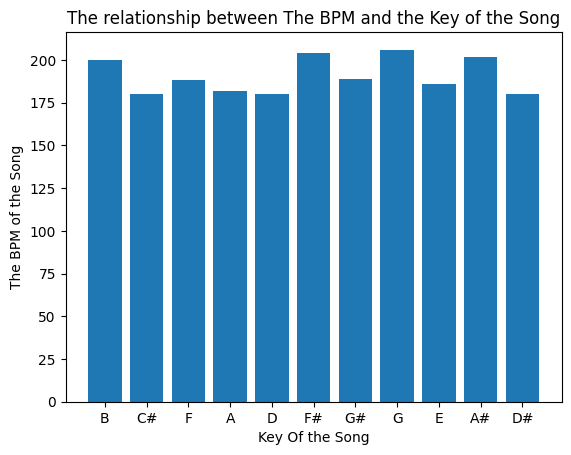

In [ ]:
plt.title("The relationship between The BPM and the Key of the Song")
plt.xlabel('Key Of the Song')
plt.ylabel('The BPM of the Song')
plt.bar(spotify_df['The Key of the Song'], spotify_df['The BPM of the Song'], label='Your Label')
plt.savefig('barpltspotify2023.svg')
plt.show()

# Step 4.9 Research Question Finalized

Do these specific features of bpm and key of songs have the effect of the number of streams or charts?

# Step 7. Creating A Linear Regression Model for the Spotify 2023 DataSet.

In [ ]:
spotify_df['The Key of the Song'] = spotify_df['The Key of the Song'].str.strip().replace({'C#': 'C♯/D♭', 'Db': 'C♯/D♭','D#': 'D♯/E♭','Eb': 'D♯/E♭', 'F#':'F♯/G♭', 'G#':'G♯/A♭','A#':'A♯/B♭'})

In [ ]:
#features = spotify_df[['The BPM of The Song', 'The Key of The Song', '']] #PlaceHolder for Linear Regression Model


key_map = {'C': 0,'C♯/D♭':1 ,'D': 2,'D♯/E♭': 3,'E': 4,'F': 5,'F♯/G♭': 6,'G': 7,'G♯/A♭':8 ,'A':9 ,'A♯/B♭':10 ,'B': 11}
major_map = {'Major': 1, 'Minor':0}
spotify_df['The Key of the Song']=spotify_df['The Key of the Song'].map(key_map)
spotify_df['The Mode of the Song']=spotify_df['The Mode of the Song'].map(major_map)

In [ ]:
spotify_df.head()

,Tracks,Artists,# of Artists on Song,Year It Released,Month It Released,Day It Released,# of Playlists The Song is in on Spotify,Song Place in Spotify Charts,# of Streams the Song has,# of Playlists The Song is in on Apple Music,...,The BPM of the Song,The Key of the Song,The Mode of the Song,How Danacable the song is by %,How Positive the Song is in %,Energy Level of the Song in %,How Much Acoustic Sound is in the Song in %,How Instrumental the Song is in %,The presence of special live performance effects in %,# of words sung in the song in %
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,11,1,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,1,1,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,5,1,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,9,1,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,9,0,65,23,80,14,63,11,6


In [ ]:
spotify_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 817 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   Tracks                                                 817 non-null    object
 1   Artists                                                817 non-null    object
 2   # of Artists on Song                                   817 non-null    int64 
 3   Year It Released                                       817 non-null    int64 
 4   Month It Released                                      817 non-null    int64 
 5   Day It Released                                        817 non-null    int64 
 6   # of Playlists The Song is in on Spotify               817 non-null    int64 
 7   Song Place in Spotify Charts                           817 non-null    int64 
 8   # of Streams the Song has                              817 non-nu

Initalizing my Features for my Linear Regression Model

In [ ]:
#spotify_df['The Key of The Song'].head()
#spotify_df['The Key of The Song']=spotify_df['The Key of The Song'].astype(int)
features = spotify_df[["The BPM of the Song","The Key of the Song","The Mode of the Song","# of words sung in the song in %","How Positive the Song is in %"]]

In [ ]:
label = spotify_df['Song Place in Spotify Charts']

Importing the Linear Regression Model


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
reg = LinearRegression()

In [ ]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(features, label, test_size=0.2, random_state=42)

In [ ]:
reg.fit(X_train, y_train)
pred = reg.predict(X_test)

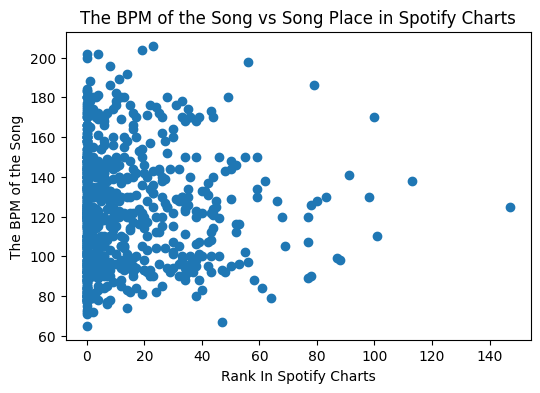

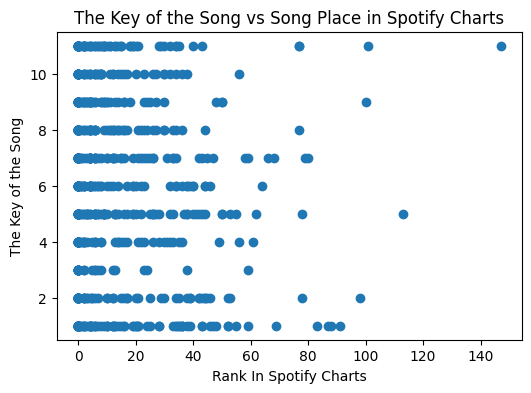

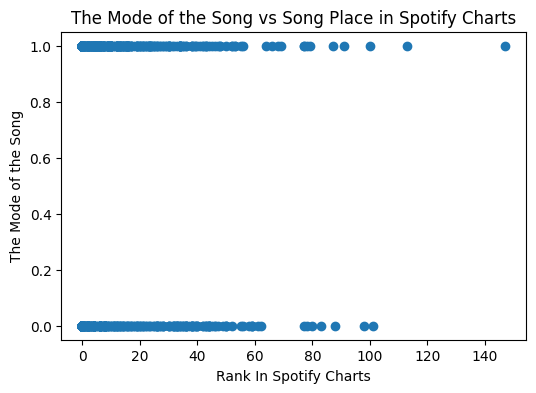

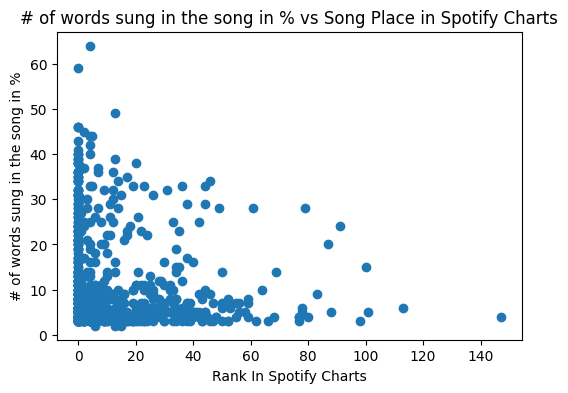

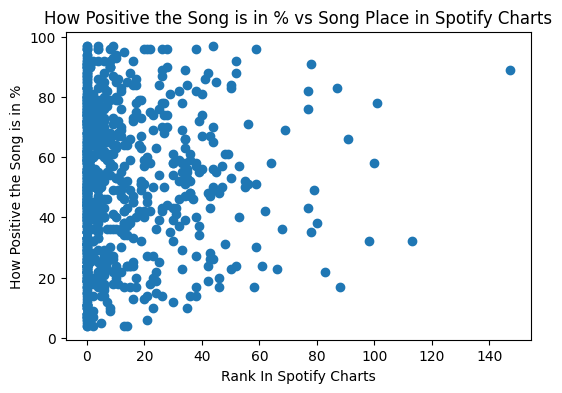

In [ ]:
features = ["The BPM of the Song","The Key of the Song","The Mode of the Song","# of words sung in the song in %","How Positive the Song is in %"]

target = spotify_df["Song Place in Spotify Charts"]

for feature in features:
    plt.figure(figsize=(6, 4))
    plt.scatter(target,spotify_df[feature])
    plt.xlabel("Rank In Spotify Charts")
    plt.ylabel(feature)
    plt.title(f"{feature} vs Song Place in Spotify Charts")
    # Clean up filename for saving
    safe_feature = feature.replace(" ", "_").replace("%", "percent").replace("#", "num").replace("/", "_")

    # Save the plots as SVG
    plt.savefig(f"{safe_feature}_vs_Rank.svg", format="svg")

    # Show the plots
    plt.show()


In [ ]:
print('mean squared: ', mean_squared_error(y_test, pred))

print('r squared: ', r2_score(y_test, pred))

mean squared:  308.12694960419554
r squared:  -0.010583065808571712
